# Exploratory Data Analysis - Appliance Energy Prediction Dataset

End-to-end EDA covering:

| Section | Content |
|---------|---------|
| 1 | Load Data & Overview |
| 2 | Data Quality (Missing values & Duplicates) |
| 3 | Target Distribution |
| 4 | Duplicated data |
| 5 | All Variables - Time Series |
| 6 | Temporal Heatmap |
| 7 | Hourly & Weekday Patterns |
| 8 | Correlation with Target |
| 9 | Full Correlation Matrix |
| 10 | Outlier Detection |
| 11 | Scatter Plots (Key Features) |
| 12 | Monthly & Weekly Patterns |
| 13 | Weekly Appliance Energy |
| 14 | Time Feature Correlations |
| 15 | weekday vs weekend mean energy consumption |
| 16 | Key Observations |


In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 4)

In [22]:
import os

PLOT_DIR = r'D:\My_Intern_Project\Plots and Visualizations'
os.makedirs(PLOT_DIR, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR}")

Plots will be saved to: D:\My_Intern_Project\Plots and Visualizations


## 1. Load Data & Basic Overview

In [ ]:
df = pd.read_csv('../data/raw/energy_data_set.csv')
df['date'] = pd.to_datetime(df['date'])

# Drop random noise variables (rv1, rv2) — no predictive value
df.drop(columns=['rv1', 'rv2'], inplace=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min()}  →  {df['date'].max()}")
print(f"Duration   : {(df['date'].max() - df['date'].min()).days} days")

Shape      : (19735, 27)
Date range : 2016-01-11 17:00:00  →  2016-05-27 18:00:00
Duration   : 137 days


In [4]:
df.describe().round(2)

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
count,19735,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,...,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00
mean,2016-03-20 05:30:00,97.69,3.80,21.69,40.26,20.34,40.42,22.27,39.24,20.86,...,22.03,42.94,19.49,41.55,7.41,755.52,79.75,4.04,38.33,3.76
min,2016-01-11 17:00:00,10.00,0.00,16.79,27.02,16.10,20.46,17.20,28.77,15.10,...,16.31,29.60,14.89,29.17,-5.00,729.30,24.00,0.00,1.00,-6.60
25%,2016-02-14 23:15:00,50.00,0.00,20.76,37.33,18.79,37.90,20.79,36.90,19.53,...,20.79,39.07,18.00,38.50,3.67,750.93,70.33,2.00,29.00,0.90
50%,2016-03-20 05:30:00,60.00,0.00,21.60,39.66,20.00,40.50,22.10,38.53,20.67,...,22.10,42.38,19.39,40.90,6.92,756.10,83.67,3.67,40.00,3.43
75%,2016-04-23 11:45:00,100.00,0.00,22.60,43.07,21.50,43.26,23.29,41.76,22.10,...,23.39,46.54,20.60,44.34,10.41,760.93,91.67,5.50,40.00,6.57
max,2016-05-27 18:00:00,1080.00,70.00,26.26,63.36,29.86,56.03,29.24,50.16,26.20,...,27.23,58.78,24.50,53.33,26.10,772.30,100.00,14.00,66.00,15.50
std,NaN,102.52,7.94,1.61,3.98,2.19,4.07,2.01,3.25,2.04,...,1.96,5.22,2.01,4.15,5.32,7.40,14.90,2.45,11.79,4.19


## 2. Missing Values

In [5]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found.")
else:
    print(missing[missing > 0])

No missing values found.


## 3. Duplicated data

In [ ]:
# Check if we have any duplicated data
any(df.duplicated())

False

## 4. Target Distribution

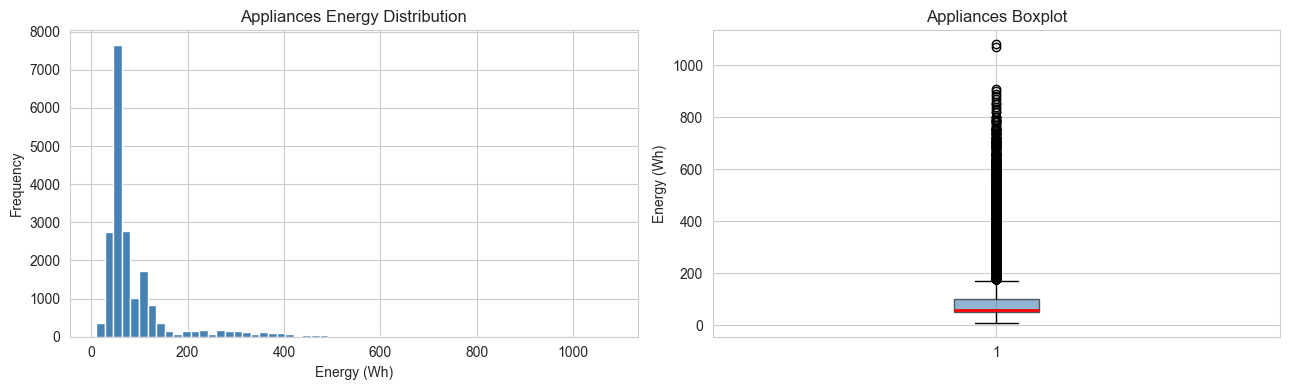

Median   : 60.0 Wh
Mean     : 97.7 Wh
Std      : 102.5 Wh
Skewness : 3.39
Max      : 1080 Wh


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Appliances'], bins=60, color='steelblue', edgecolor='white')
axes[0].set(title='Appliances Energy Distribution', xlabel='Energy (Wh)', ylabel='Frequency')

axes[1].boxplot(df['Appliances'], patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set(title='Appliances Boxplot', ylabel='Energy (Wh)')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '01_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Median   : {df['Appliances'].median():.1f} Wh")
print(f"Mean     : {df['Appliances'].mean():.1f} Wh")
print(f"Std      : {df['Appliances'].std():.1f} Wh")
print(f"Skewness : {df['Appliances'].skew():.2f}")
print(f"Max      : {df['Appliances'].max()} Wh")

## 5. General view of the whole dataset

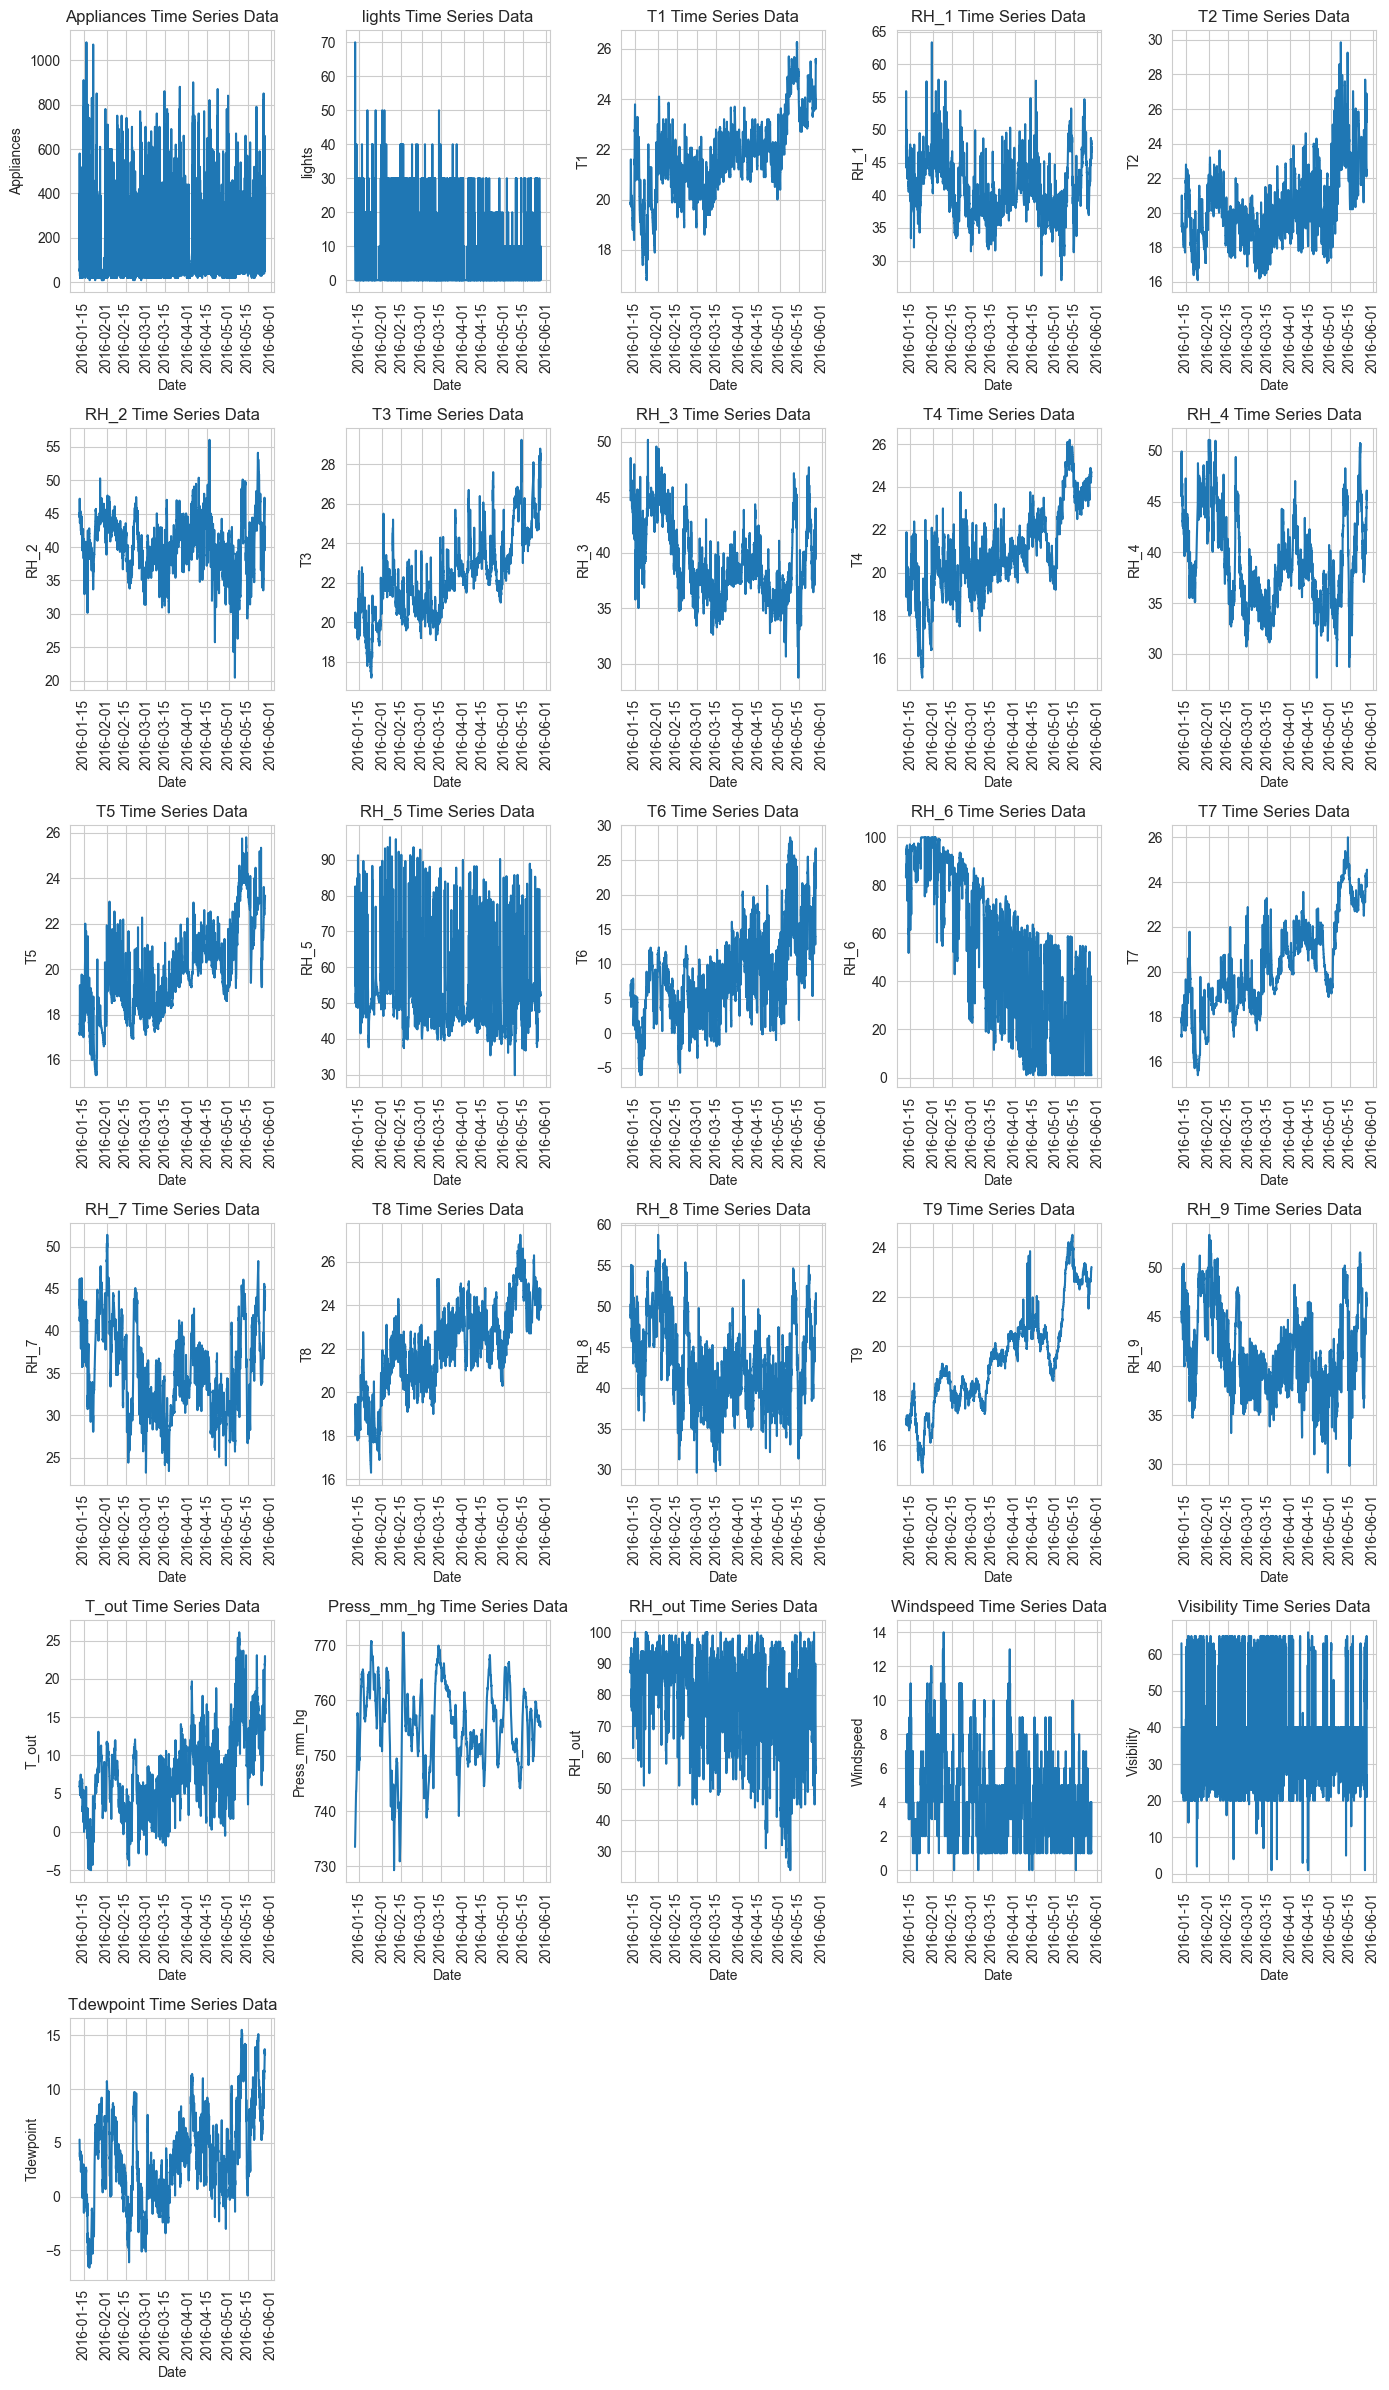

In [ ]:
selected_columns = df.columns.tolist()
date_column_index = selected_columns.index('date')
selected_columns = selected_columns[:date_column_index] + selected_columns[date_column_index+1:]

num_cols = len(selected_columns)
num_rows = (num_cols - 1) // 5 + 1

fig, axs = plt.subplots(num_rows, 5, figsize=(14, num_rows*4))

for i in range(num_rows):
    for j in range(5):
        index = i * 5 + j
        if index < num_cols:
            var = selected_columns[index]
            sns.lineplot(y=df[var], x=df['date'], ax=axs[i,j], linewidth=1.5)
            axs[i,j].set_xlabel('Date')
            axs[i,j].set_ylabel(var)
            axs[i,j].set_title('{} Time Series Data'.format(var))
            axs[i,j].tick_params(axis='x', rotation=90)
        else:
            axs[i,j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '02_Feature_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Time Series Overview

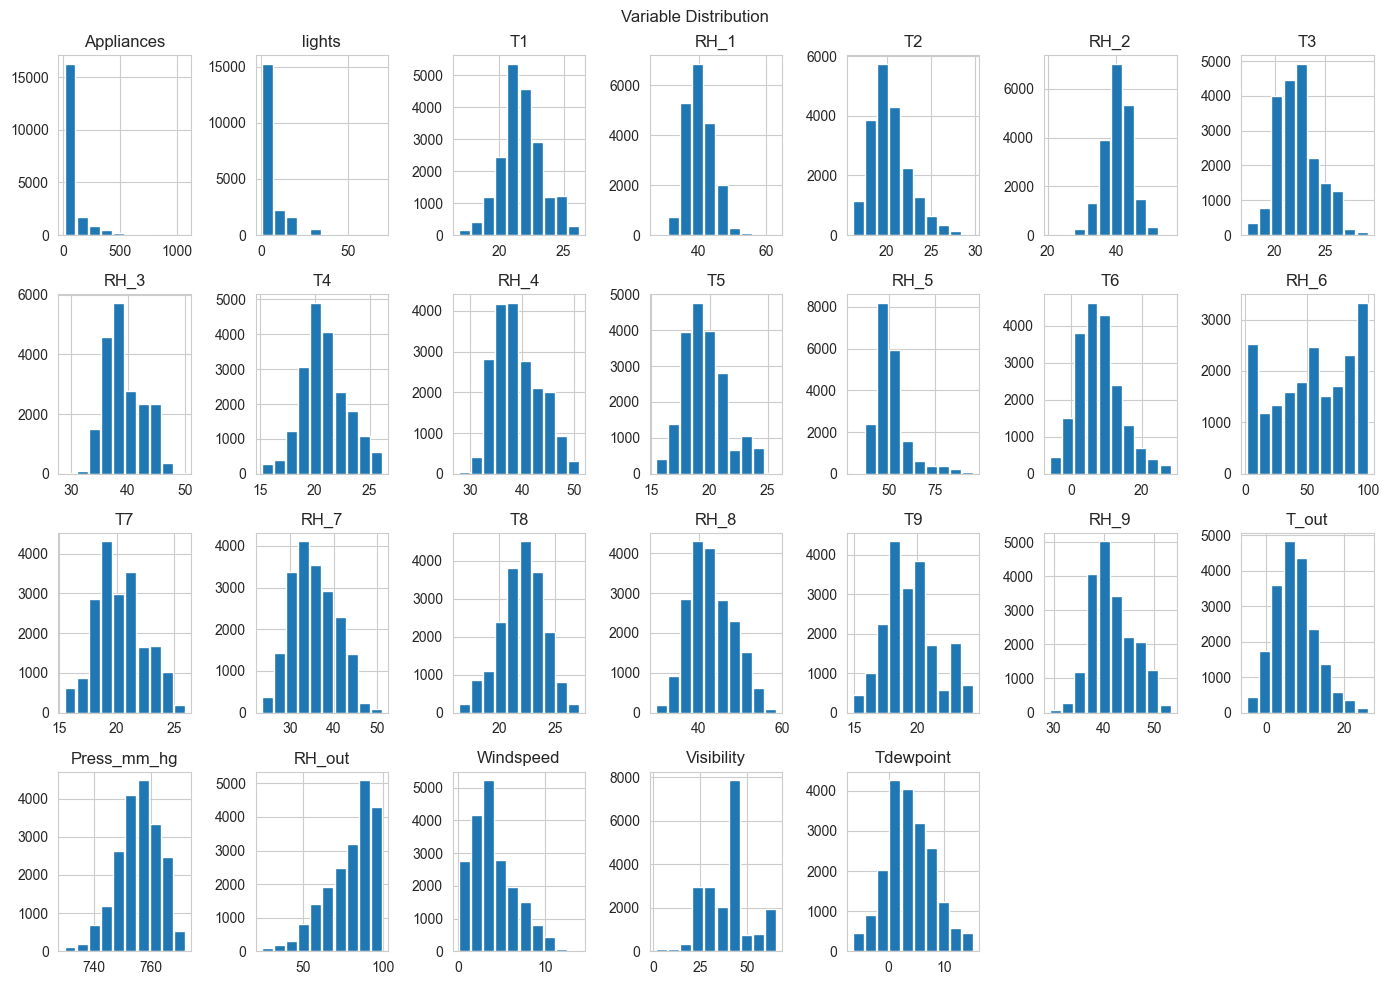

In [ ]:
numerical = df.columns[1:]

fig, axs = plt.subplots(4, 7, figsize=(14, 10))

cpt = 0

for i in range(4):
    for j in range(7):
        if cpt < len(numerical):
            var = numerical[cpt]
            axs[i,j].hist(df[var].values, rwidth=0.9)
            axs[i,j].set_title(var)
            cpt += 1
        else:
            axs[i,j].axis('off')

fig.suptitle('Variable Distribution')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '03_Variable Distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


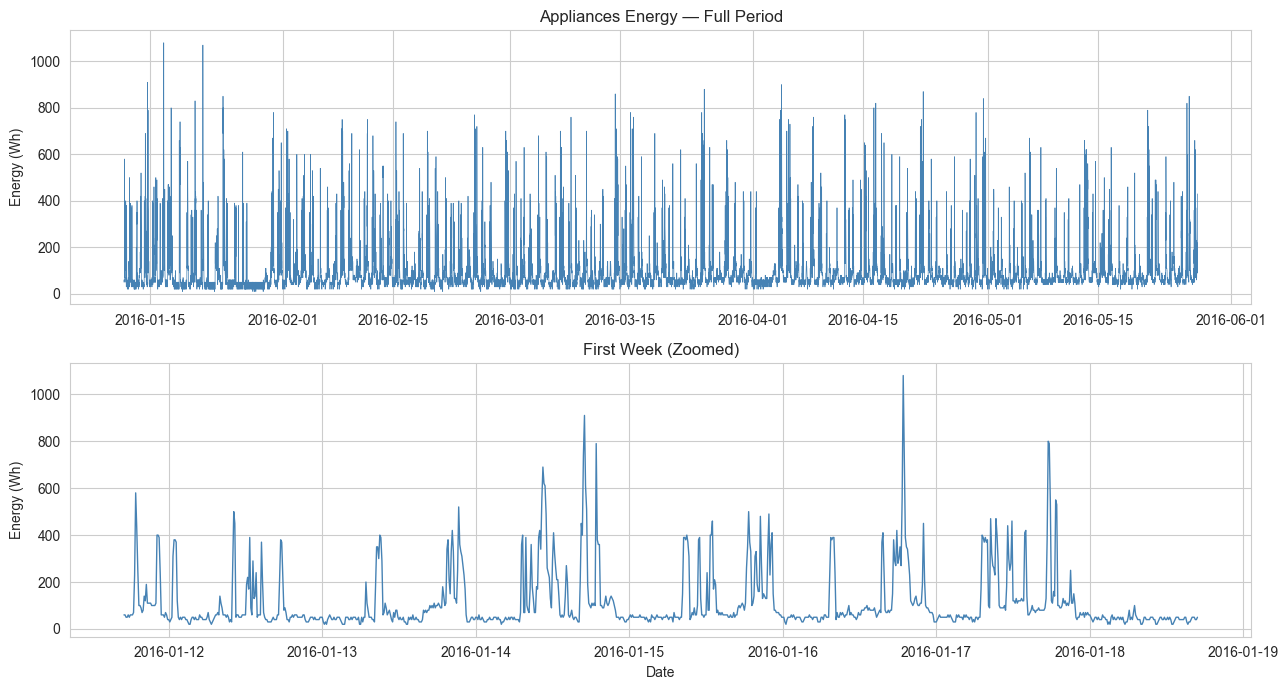

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(df['date'], df['Appliances'], linewidth=0.5, color='steelblue')
axes[0].set(title='Appliances Energy — Full Period', ylabel='Energy (Wh)')

week = df[df['date'] < df['date'].min() + pd.Timedelta(days=7)]
axes[1].plot(week['date'], week['Appliances'], linewidth=1, color='steelblue')
axes[1].set(title='First Week (Zoomed)', xlabel='Date', ylabel='Energy (Wh)')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '04_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. Temporal Heatmap (Hour × Day of Week)

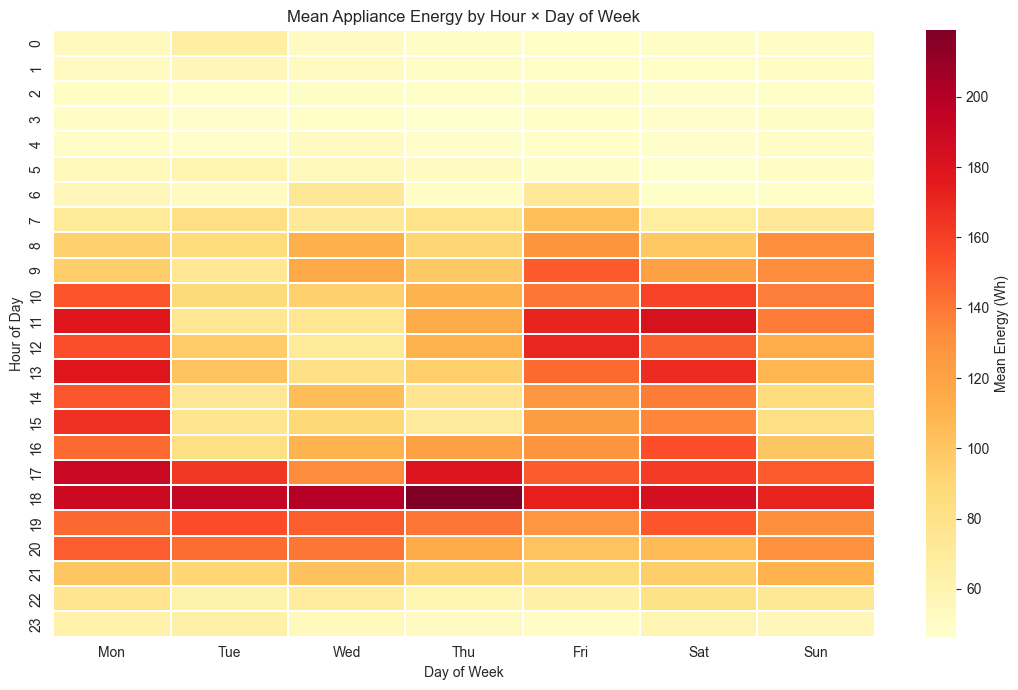

In [ ]:
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek   # 0=Mon, 6=Sun
df['NSM']         = df['hour'] * 3600 + df['date'].dt.minute * 60

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = df.pivot_table('Appliances', index='hour', columns='day_of_week', aggfunc='mean')
pivot.columns = day_labels

plt.figure(figsize=(11, 7))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Mean Energy (Wh)'})
plt.title('Mean Appliance Energy by Hour × Day of Week')
plt.ylabel('Hour of Day')
plt.xlabel('Day of Week')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '05_hourly_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. Hourly and Weekday Patterns

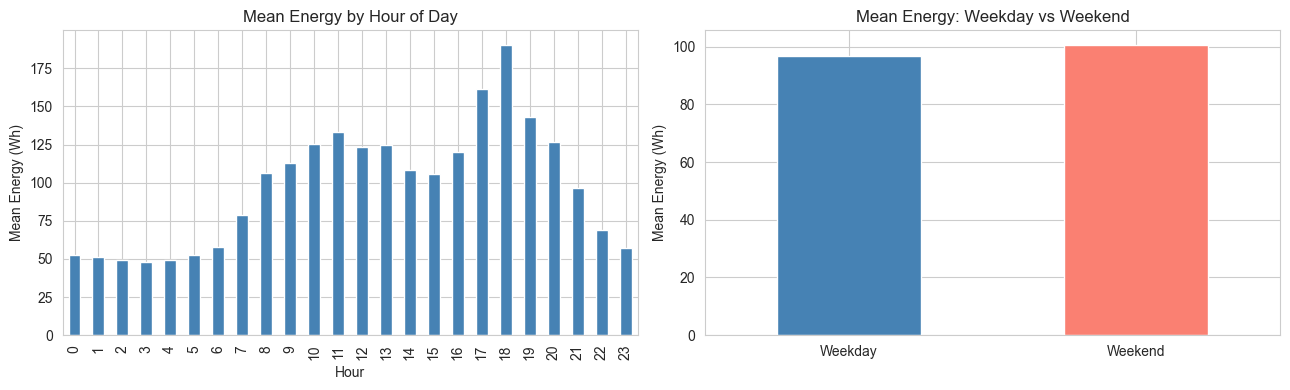

In [ ]:
df['is_weekend'] = df['day_of_week'].isin([5, 6])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hourly mean
df.groupby('hour')['Appliances'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set(title='Mean Energy by Hour of Day', xlabel='Hour', ylabel='Mean Energy (Wh)')

# Weekday vs Weekend
df.groupby('is_weekend')['Appliances'].mean().rename({False: 'Weekday', True: 'Weekend'}).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'salmon'], rot=0)
axes[1].set(title='Mean Energy: Weekday vs Weekend', ylabel='Mean Energy (Wh)', xlabel='')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '07_hourly_and_weekday.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Correlation with Target

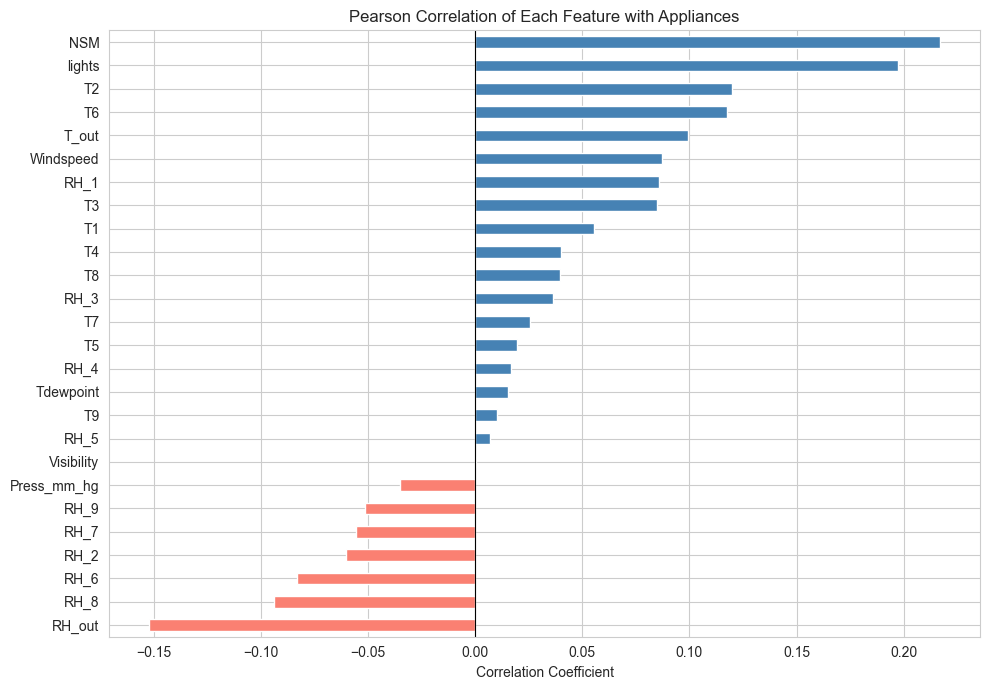

In [14]:
num_cols = df.select_dtypes(include=np.number).columns.drop(['hour', 'day_of_week', 'is_weekend'], errors='ignore')
corr_target = df[num_cols].corr()['Appliances'].drop('Appliances').sort_values()

colors = ['salmon' if v < 0 else 'steelblue' for v in corr_target]
corr_target.plot(kind='barh', color=colors, figsize=(10, 7))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation of Each Feature with Appliances')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '08_correlation_with_target.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Full Correlation Matrix

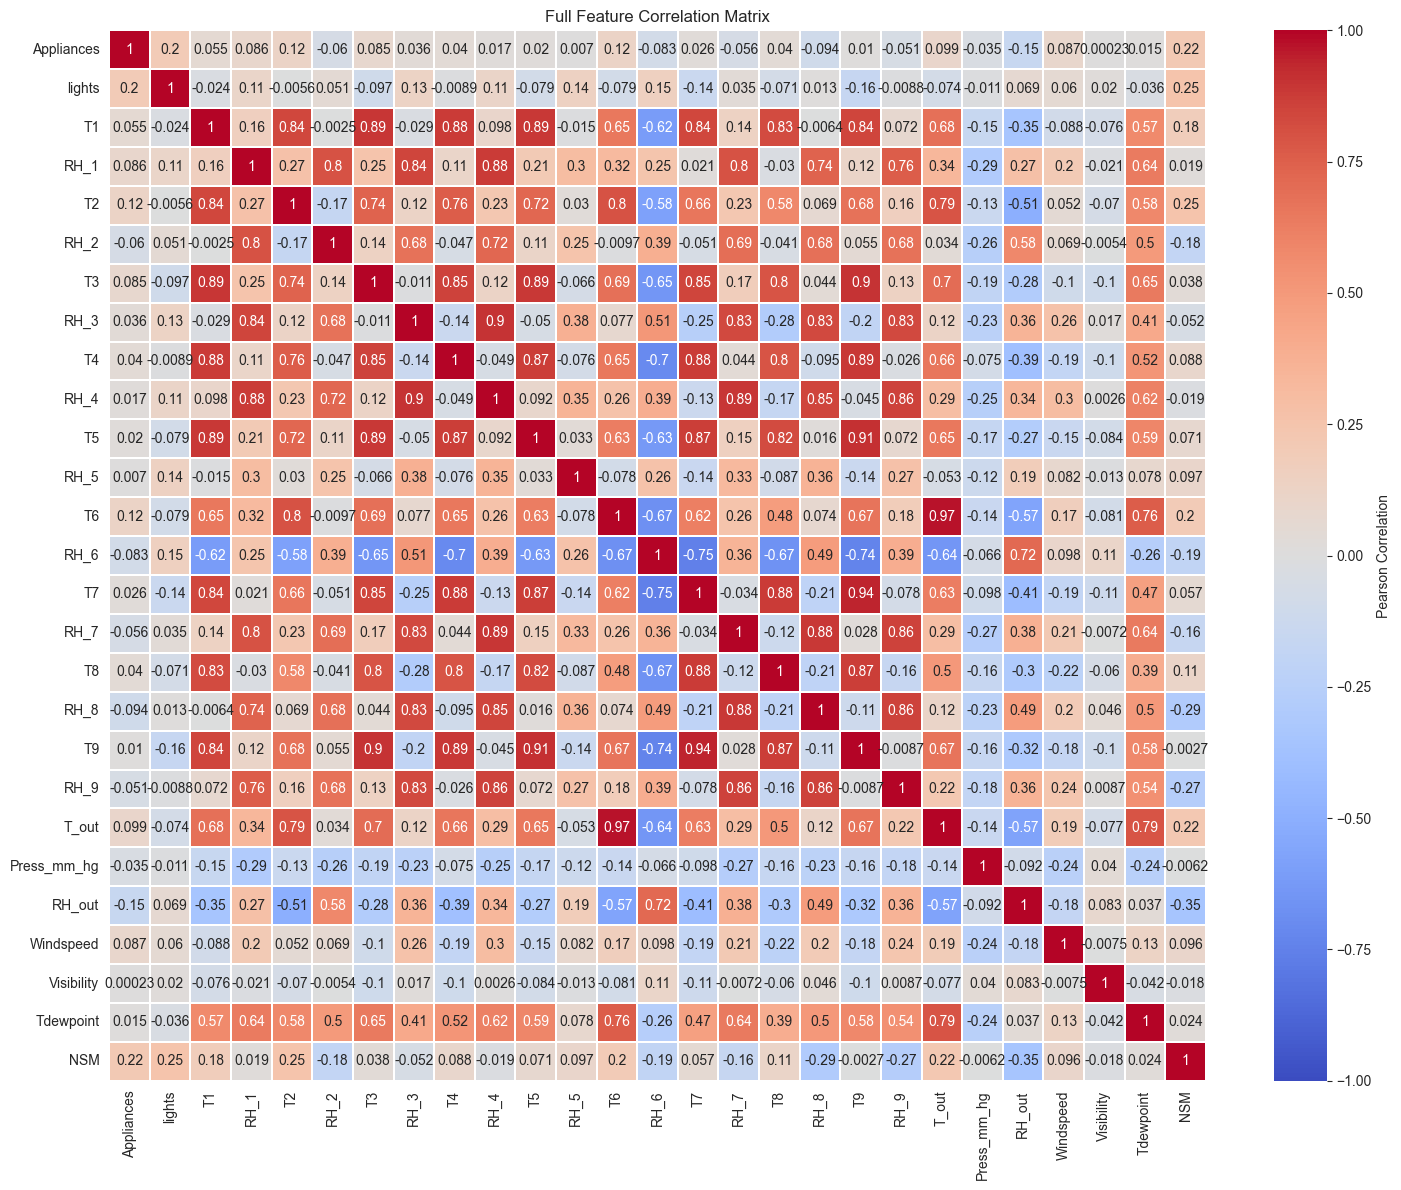

In [24]:
plt.figure(figsize=(15, 12))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0,
            annot=True, linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Full Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '09_full_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Outlier Detection

IQR bounds : [-25.0,  175.0] Wh
Outliers   : 2138 records  (10.8% of data)


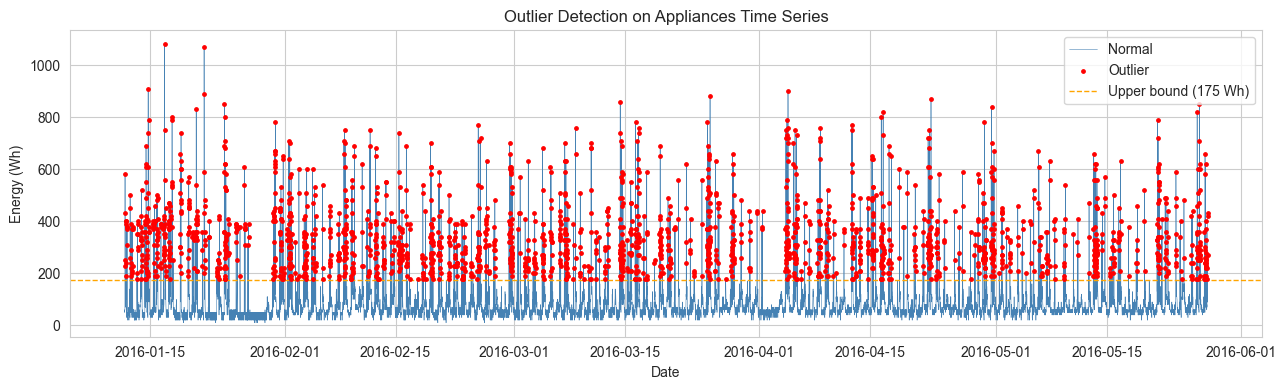

In [ ]:
Q1, Q3 = df['Appliances'].quantile([0.25, 0.75])
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR

outliers = df[(df['Appliances'] < lower) | (df['Appliances'] > upper)]

print(f"IQR bounds : [{lower:.1f},  {upper:.1f}] Wh")
print(f"Outliers   : {len(outliers)} records  ({len(outliers)/len(df)*100:.1f}% of data)")

plt.figure(figsize=(13, 4))
plt.plot(df['date'], df['Appliances'], linewidth=0.4, color='steelblue', label='Normal')
plt.scatter(outliers['date'], outliers['Appliances'], color='red', s=6, zorder=5, label='Outlier')
plt.axhline(upper, color='orange', linestyle='--', linewidth=1, label=f'Upper bound ({upper:.0f} Wh)')
plt.title('Outlier Detection on Appliances Time Series')
plt.xlabel('Date')
plt.ylabel('Energy (Wh)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '10_outlier_detection.png'), dpi=150, bbox_inches='tight')
plt.show()


## 11. Scatter Plots (Key Features)

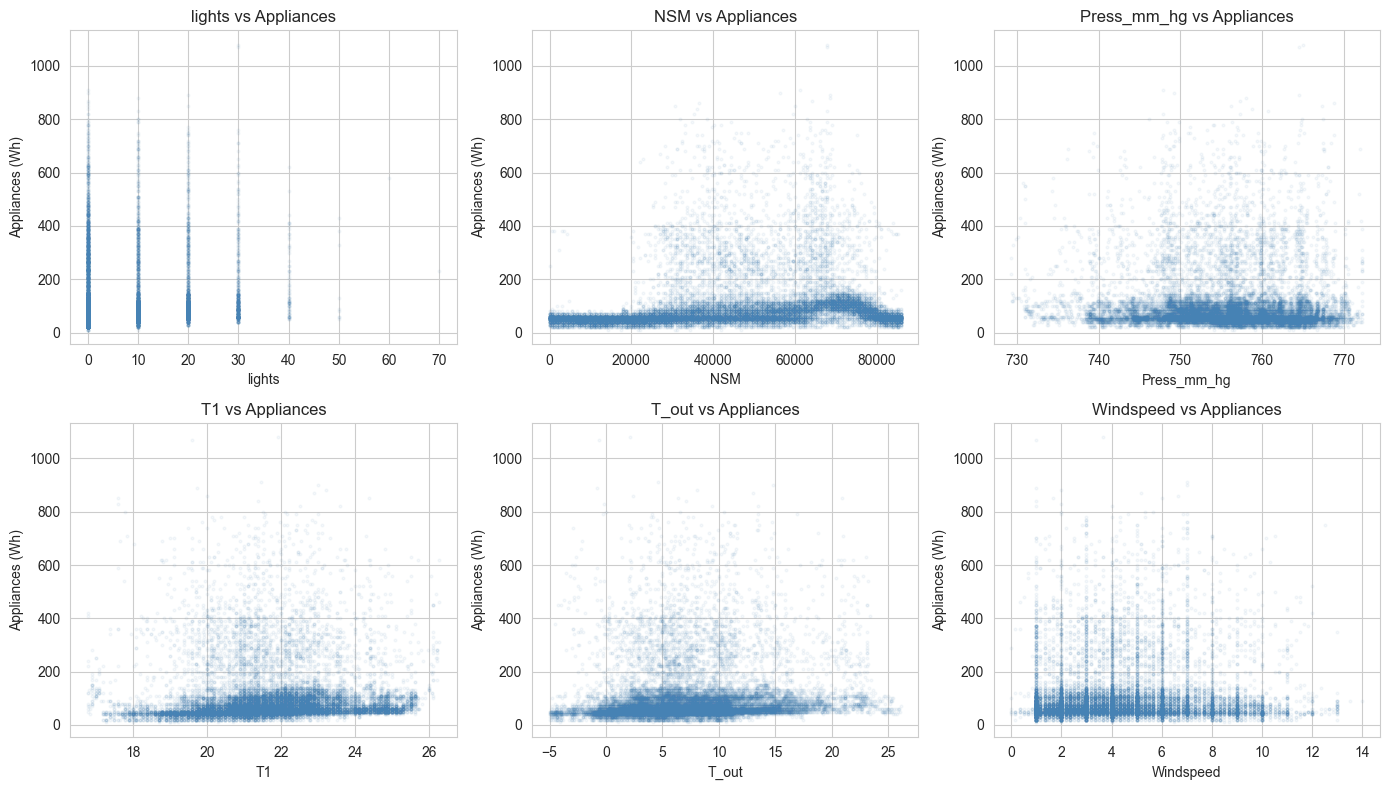

In [17]:
features = ['lights', 'NSM', 'Press_mm_hg', 'T1', 'T_out', 'Windspeed']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df[feat], df['Appliances'], alpha=0.05, s=4, color='steelblue')
    ax.set(xlabel=feat, ylabel='Appliances (Wh)', title=f'{feat} vs Appliances')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '11_scatter_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Monthly and Weekly Patterns

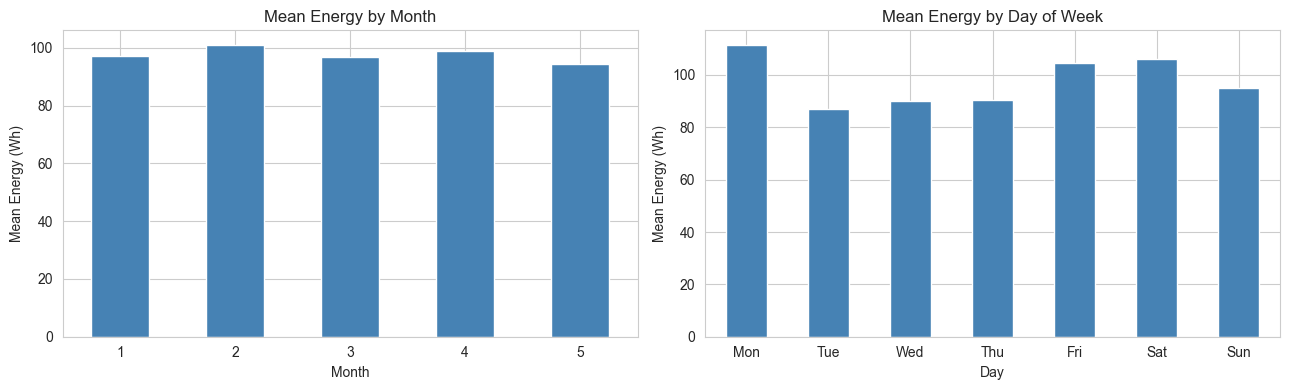

In [18]:
df['month'] = df['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('month')['Appliances'].mean().plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set(title='Mean Energy by Month', xlabel='Month', ylabel='Mean Energy (Wh)')

df.groupby('day_of_week')['Appliances'].mean().rename(
    dict(enumerate(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))).plot(
    kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set(title='Mean Energy by Day of Week', xlabel='Day', ylabel='Mean Energy (Wh)')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '12_monthly_weekly.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Weekly Appliance Energy

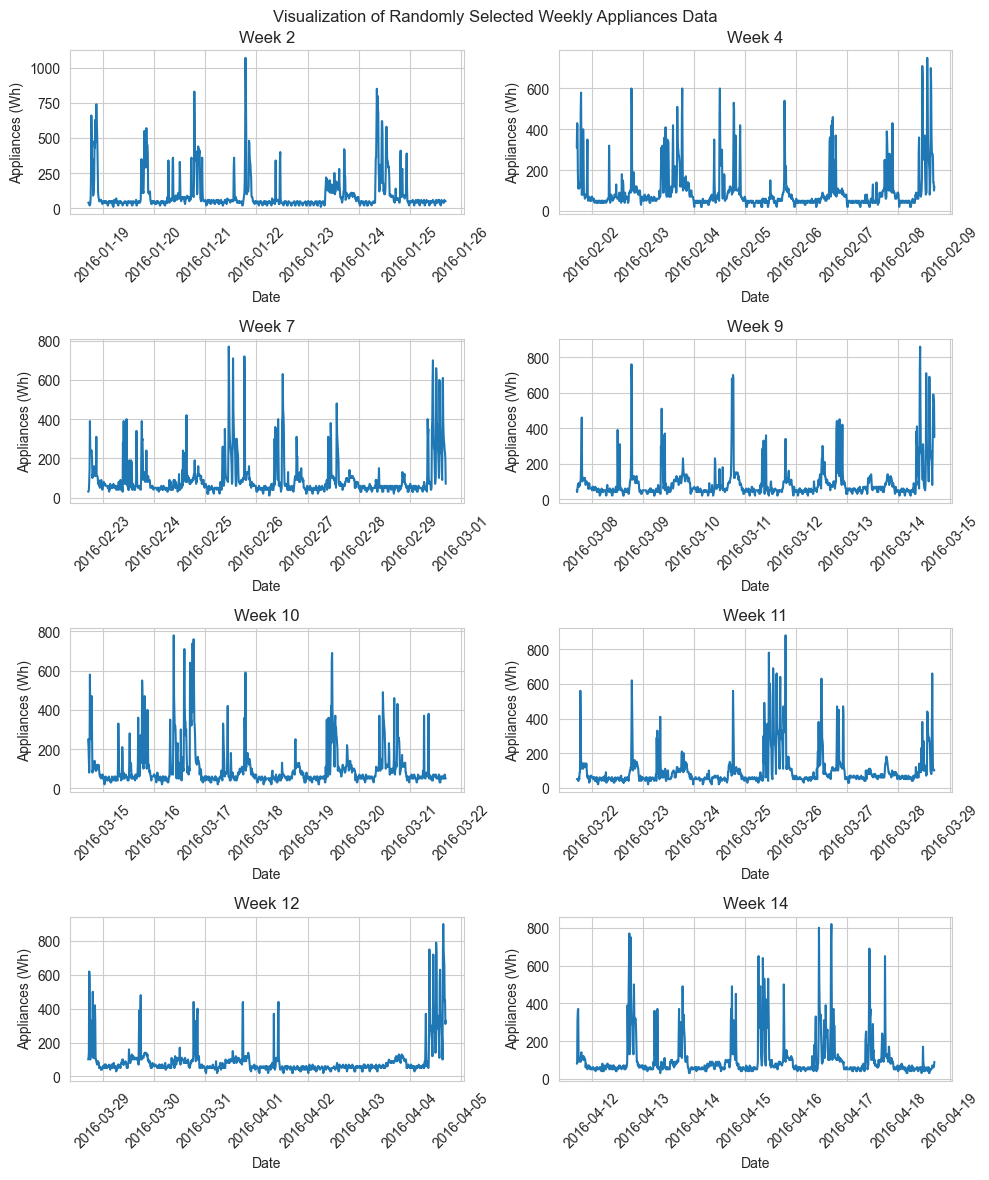

In [ ]:
len_weekly_data = 6*24*7

def select_random_weeks(data):
    num_weeks = len(data) // len_weekly_data
    random_week_indices = random.sample(range(num_weeks), 8)
    random_week_indices.sort()
    return random_week_indices

random_week_indices = select_random_weeks(df)

start_indices = [i * len_weekly_data for i in random_week_indices]
end_indices = [s + len_weekly_data for s in start_indices]

week_data = [df.iloc[start:end] for start, end in zip(start_indices, end_indices)]

fig, axs = plt.subplots(4, 2, figsize=(10, 12))
fig.suptitle('Visualization of Randomly Selected Weekly Appliances Data')

for i, ax in enumerate(axs.flatten()):
    week = week_data[i]
    
    ax.plot(week['date'], week['Appliances'], color='#1f77b4', linestyle='-')
    ax.set_title(f'Week {random_week_indices[i] + 1}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Appliances (Wh)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '13_Weekly Appliance Energy.png'), dpi=150, bbox_inches='tight')
plt.show()


## 14. Correlation of Time-Based Features with Appliances

In [24]:
# Ensure time columns exist
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek          # 0=Mon, 6=Sun
df['month']       = df['date'].dt.month
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

time_features = ['hour', 'day_of_week', 'month', 'is_weekend']

# Pearson correlation with Appliances
corr_values = {f: df[f].corr(df['Appliances']) for f in time_features}
corr_df = pd.DataFrame.from_dict(corr_values, orient='index', columns=['Pearson r'])
corr_df['|r|'] = corr_df['Pearson r'].abs()
corr_df = corr_df.sort_values('|r|', ascending=False)

print("Pearson correlation with Appliances:")
print(corr_df.round(4).to_string())

Pearson correlation with Appliances:
             Pearson r     |r|
hour            0.2168  0.2168
is_weekend      0.0174  0.0174
month          -0.0116  0.0116
day_of_week     0.0031  0.0031


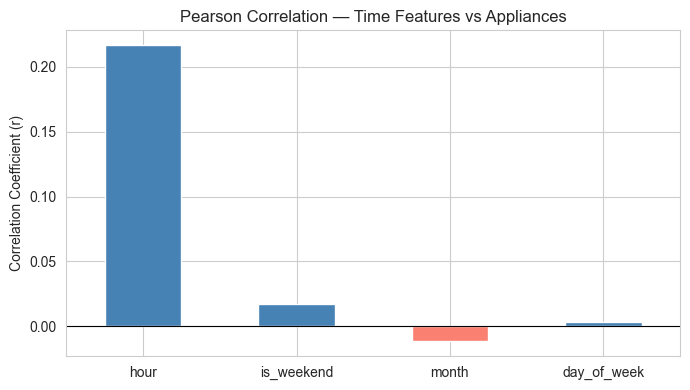

In [ ]:
# Bar chart of correlation magnitudes
colors = ['steelblue' if v >= 0 else 'salmon' for v in corr_df['Pearson r']]
corr_df['Pearson r'].plot(kind='bar', color=colors, figsize=(7, 4), rot=0)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation - Time Features vs Appliances')
plt.ylabel('Correlation Coefficient (r)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '14_timefeat_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. weekday vs weekend mean energy consumption

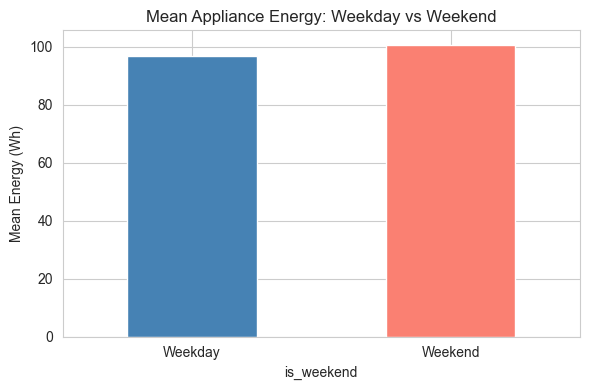

In [ ]:
# Comparing weekday vs weekend mean energy consumption
plt.figure(figsize=(6, 4))
df.groupby('is_weekend')['Appliances'].mean().rename({False: 'Weekday', True: 'Weekend'}).plot(
    kind='bar', color=['steelblue', 'salmon'], rot=0)
plt.title('Mean Appliance Energy: Weekday vs Weekend')
plt.ylabel('Mean Energy (Wh)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '15_weekday_weekend_comparison.png'), dpi=150, bbox_inches='tight')
plt.show(
)

## 16. Key Observations

| Finding | Detail |
|---------|--------|
| **No missing values** | Dataset is complete , So no imputation needed |
  **No duplicates** | Each row is unique , no redundancy |
| **Highly skewed target** | Median ≈ 60 Wh but spikes to 1200+ Wh; right-skewed distribution |
| **Strong daily cycle** | Energy rises ~6am, peaks ~noon, rises again ~6pm |
| **NSM is the top correlate** | Time-of-day is the strongest single predictor |
| **Lights is a strong proxy** | High positive correlation , acts as an occupancy indicator |
| **Pressure is important** | Pressure negatively correlates with wind speed; linked to occupancy via weather |
| **High inter-sensor temp correlation** | T1-T9 are highly inter-correlated - multicollinearity to handle |
| **Outliers present (~10%)** | High-energy spikes are real events, not noise - cap rather than remove |
| **rv1 & rv2 dropped** | Random variables with no predictive power, removed at load time |